313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 270us/step - accuracy: 0.9807 - loss: 0.1842
Without BN: 0.9807000160217285
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 285us/step - accuracy: 0.9775 - loss: 0.0777
With BN: 0.9775000214576721


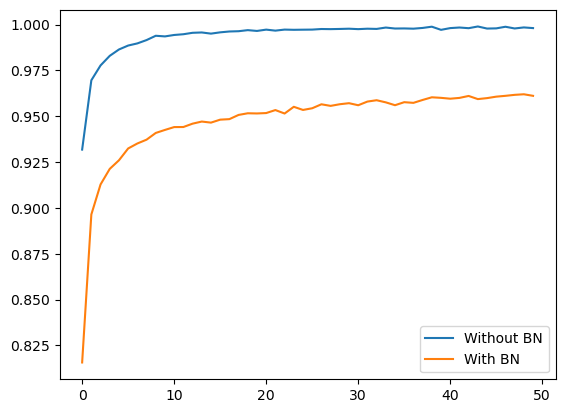

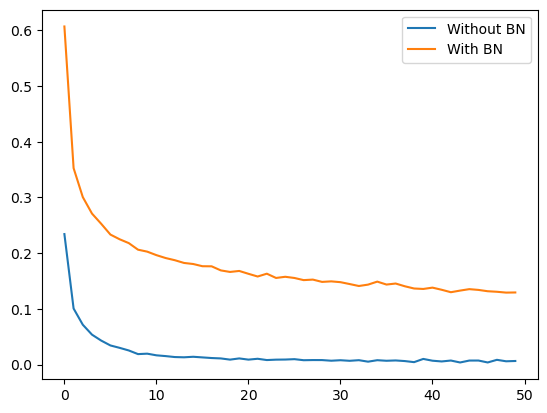

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.reshape(-1,784)/255.0
x_test = x_test.reshape(-1,784)/255.0

model1 = Sequential()

model1.add(Input(shape=(784,)))
model1.add(Dense(128, activation='relu'))
model1.add(Dense(64, activation='relu'))
model1.add(Dense(10, activation='softmax'))

model1.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

h1 = model1.fit(x_train, y_train,epochs=50,verbose=0)

model2 = Sequential()

model2.add(Input(shape=(784,)))
model2.add(Dense(128, activation='relu'))
model2.add(BatchNormalization())
model2.add(Dropout(0.5))

model2.add(Dense(64, activation='relu'))
model2.add(BatchNormalization())
model2.add(Dropout(0.5))

model2.add(Dense(10, activation='softmax'))

model2.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

h2 = model2.fit(x_train, y_train,epochs=50,verbose=0)

print("Without BN:", model1.evaluate(x_test, y_test)[1])
print("With BN:", model2.evaluate(x_test, y_test)[1])

plt.plot(h1.history['accuracy'], label='Without BN')
plt.plot(h2.history['accuracy'], label='With BN')
plt.legend()
plt.show()

plt.plot(h1.history['loss'], label='Without BN')
plt.plot(h2.history['loss'], label='With BN')
plt.legend()
plt.show()


# Viva Questions and Answers

## 1. What is Batch Normalization?

Batch Normalization is a technique that normalizes the output of a layer by maintaining a stable mean and variance. It improves training speed and stability.

---

## 2. Why is Batch Normalization used?

* Speeds up training
* Stabilizes learning
* Allows higher learning rates
* Reduces internal covariate shift

---

## 3. What is Internal Covariate Shift?

Internal covariate shift is the change in the distribution of layer inputs during training, making learning slower. Batch Normalization reduces this effect.

---

## 4. What is Dropout?

Dropout is a regularization technique that randomly disables a fraction of neurons during training to reduce overfitting.

---

## 5. Why is Dropout used?

* Prevents overfitting
* Improves generalization
* Forces different neurons to learn useful features

---

## 6. What does `Dropout(0.5)` mean?

It means 50% of the neurons are randomly deactivated during each training iteration.

---

## 7. Difference between Batch Normalization and Dropout

| Batch Normalization         | Dropout                 |
| --------------------------- | ----------------------- |
| Normalizes activations      | Randomly drops neurons  |
| Improves training stability | Prevents overfitting    |
| Speeds up convergence       | Improves generalization |

---

## 8. Why is the dataset normalized?

The pixel values are divided by 255 to scale them between 0 and 1, improving convergence during training.

---

## 9. Why is the dataset reshaped to `(784,)`?

The Dense layer accepts a one-dimensional input vector. Therefore, each 28×28 image is flattened into 784 features.

---

## 10. Why is `Input(shape=(784,))` used?

It defines the input shape for the neural network and is the recommended approach in Keras 3.

---

## 11. Why are two identical models used?

To compare the effect of Batch Normalization and Dropout while keeping the network architecture the same.

---

## 12. Why is the Adam optimizer used?

Adam provides adaptive learning rates and faster convergence compared to traditional optimizers.

---

## 13. Why is `sparse_categorical_crossentropy` used?

It is suitable for multi-class classification problems where labels are integers.

---

## 14. What does `validation_data` do?

It evaluates the model on the test dataset after every epoch and records validation accuracy and validation loss.

---

## 15. Why are accuracy and loss plotted?

Accuracy shows how correctly the model classifies images, while loss indicates how well the model is minimizing prediction error.

---

## 16. Why is the Batch Normalization model showing lower training accuracy?

Because Dropout randomly disables neurons during training, making learning harder. This reduces training accuracy but improves generalization.

---

## 17. Why is the Batch Normalization model showing higher training loss?

Dropout intentionally makes optimization more difficult by removing neurons during training, resulting in higher training loss.

---

## 18. Which model learns faster?

The model without Batch Normalization and Dropout learns faster because all neurons participate in every training iteration.

---

## 19. Which model generalizes better?

The model with Batch Normalization and Dropout generally generalizes better because regularization reduces overfitting.

---

## 20. What is overfitting?

Overfitting occurs when a model memorizes the training data and performs poorly on unseen test data.

---

## 21. What is generalization?

Generalization is the ability of a trained model to perform well on unseen or new data.

---

## 22. Explain the workflow of this experiment.

```text
Load Dataset
      ↓
Normalize
      ↓
Flatten Images
      ↓
Model Without Batch Normalization
      ↓
Train and Evaluate
      ↓
Model With Batch Normalization + Dropout
      ↓
Train and Evaluate
      ↓
Compare Accuracy
      ↓
Compare Loss Curves
```

---

## 23. Why compare two models?

To study the effect of Batch Normalization and Dropout on training speed, accuracy, loss, and generalization.

---

## 24. Conclusion of the experiment

The model without Batch Normalization achieves higher training accuracy and lower training loss. The model with Batch Normalization and Dropout trains more slowly due to regularization but generally provides better generalization by reducing overfitting.

---

## 25. What is the main objective of this experiment?

To compare the performance of neural networks with and without Batch Normalization and observe the effect of Dropout on reducing overfitting and improving model generalization.
